# DATA PREPROCESSING

## Loading Data

In [1]:
import datasets
from datasets import load_dataset

tldr = load_dataset("webis/tldr-17", split = 'train') # there is only train 

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\datasets\table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [2]:
# 3 random examples from the Webis-TLDR-17 TIFU dataset:
import random

def show_random_elements(dataset, num_examples=3):
    picks = random.sample(range(len(dataset)), num_examples)
    for i in picks:
        print(dataset[i])
        print("---")

show_random_elements(tldr)

{'author': 'SuedeAsian', 'body': "I have truly enjoyed mine actually! I go to a private Christian school and I got 2 weeks off! For the first couple of days in the first week I just relaxed and texted people, going out every now and then to hang out with friends. \n\nOn Christmas eve my family departed for Sacramento (We live 4 hours away) to see my mom's side of the family. I absolutely love it there because, since I don't see them much and since they are so overly extraverted, I find it extremely easy to open up to them and act like a total idiot(2 ESFP's, 1 ESTP, and I think an ENTP). Since I don't see them much then I don't think I would ever have a problem with them or how they are unorganized or anything like that.  \n\nThen the next day I went to San Fran to see my dad's side. There I just played video games with my cousins (The introverted side for sure). I also went to the mall with them so I could buy a 3DS-which definitely made my drive back more entertaining.\n\nThe next da

## Subreddit Selection

In [3]:
subreddit_count = {}

for subreddit in tldr['subreddit']:
    subreddit_count[subreddit] = subreddit_count.get(subreddit, 0) + 1
subreddit_count

{'math': 1938,
 'funny': 40171,
 'Borderlands': 1506,
 'gamingpc': 553,
 'Diablo': 6860,
 'RedditLaqueristas': 402,
 'apple': 4612,
 'RedditFilmsProduction': 1,
 'AbandonedPorn': 110,
 'atheism': 43268,
 'quotes': 106,
 'AskReddit': 589947,
 'personalfinance': 14403,
 'Animals': 58,
 'leagueoflegends': 109307,
 'videos': 20567,
 'trees': 47286,
 'Games': 11820,
 'rawdenim': 491,
 'BMW': 580,
 'Guitar': 5135,
 'tf2': 7152,
 'truegaming': 5647,
 'swtor': 3681,
 'anime': 5868,
 'relationship_advice': 50416,
 'TwoXChromosomes': 21562,
 'AdviceAnimals': 40783,
 'Minecraft': 8983,
 'motorcycles': 7457,
 'firefall': 248,
 'audiophile': 1175,
 'SRSDiscussion': 642,
 'explainlikeimfive': 25482,
 'WTF': 25781,
 'linux': 2751,
 'LambdaConspiracies': 3,
 'YouShouldKnow': 1045,
 'fffffffuuuuuuuuuuuu': 8542,
 'cars': 4560,
 'TrueAskReddit': 968,
 'boardgames': 3015,
 'childfree': 4364,
 'business': 1096,
 'starcraft': 12911,
 'antisrs': 246,
 'todayilearned': 25004,
 'festivals': 85,
 'askseddit': 3

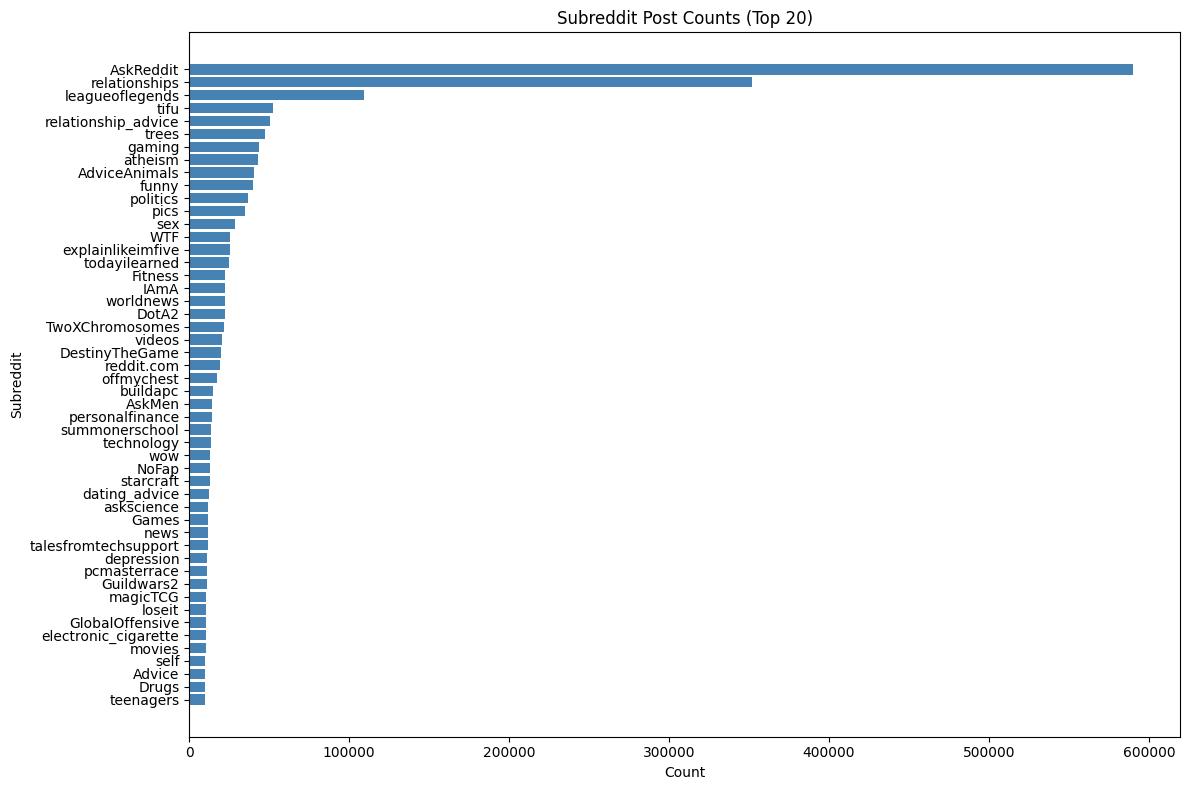

In [5]:
import matplotlib.pyplot as plt

# Sort by count descending and take top 20
sorted_counts = sorted(subreddit_count.items(), key=lambda x: x[1], reverse=True)[:50]
subreddits, counts = zip(*sorted_counts)

plt.figure(figsize=(12, 8))
plt.barh(subreddits, counts, color='steelblue')
plt.xlabel('Count')
plt.ylabel('Subreddit')
plt.title('Subreddit Post Counts (Top 20)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()